In [15]:
from src.process_data import run_processing_data
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, Any, List
import pandas as pd

def load_sop_json(path: str | Path) -> Dict[str, Any]:
    """
    Lê o arquivo JSON do SOP e retorna o dicionário completo.
    """
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def sop_results_to_dataframe(data: Dict[str, Any]) -> pd.DataFrame:
    """
    Converte o dicionário carregado (load_sop_json) em um DataFrame 'long'
    com colunas: order_percolation, color, rho, time, pt, nt, Mt,
    time_percolation, shortest_path_lin.
    """
    rows: List[Dict[str, Any]] = []
    for entry in data.get("results", []):
        order = entry.get("order_percolation")
        d = entry.get("data", {})
        color = d.get("color")
        rho = d.get("rho")
        tperc = d.get("time_percolation")
        spl = d.get("shortest_path_lin")
        time = d.get("time", [])
        pt = d.get("pt", [])
        nt = d.get("nt", [])
        Mt = d.get("Mt", [])

        # garante mesmo comprimento (corta pelo menor)
        n = min(len(time), len(pt), len(nt), len(Mt))
        for i in range(n):
            rows.append({
                "order_percolation": order,
                "color": color,
                "rho": rho,
                "time": time[i],
                "pt": pt[i],
                "nt": nt[i],
                "Mt": Mt[i],
                "time_percolation": tperc,
                "shortest_path_lin": spl,
            })
    return pd.DataFrame(rows)


In [10]:

# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean","M_size_mean", 'M_size_erro']).copy()


# ver somente um range de colunas
df_clean_3d

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro,M_size_mean,M_size_erro,perc_rate
0,bond,1.0,3.0,128.0,1600.0,0.000010,1.000000,0.3,1.0,1.0,1.0,0.258624,0.000000,1596.745098,0.000000,6.135520e+05,0.000000,1.000
1,bond,1.0,3.0,128.0,1600.0,0.000010,1.000000,1.0,1.0,1001.0,1001.0,0.258528,0.000018,1597.241842,0.095660,6.744892e+05,900.077797,1.000
2,bond,1.0,3.0,256.0,6500.0,0.000003,1.000000,0.3,1.0,561.0,561.0,0.257911,0.000009,6500.489132,0.080683,5.340340e+06,5719.025296,1.000
3,bond,1.0,3.0,256.0,6500.0,0.000003,1.000000,0.7,1.0,500.0,500.0,0.257914,0.000010,6500.450169,0.087660,5.438791e+06,6174.521414,1.000
4,bond,1.0,3.0,256.0,6500.0,0.000003,1.000000,1.0,1.0,500.0,500.0,0.257923,0.000010,6500.453569,0.089325,5.519814e+06,6456.957771,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11624,bond,8.0,3.0,256.0,6500.0,0.000003,0.090218,1.0,3.0,500.0,407.0,1.000000,0.000000,185.542342,4.394476,2.719491e+05,6263.211721,0.814
11625,bond,8.0,3.0,256.0,6500.0,0.000003,0.090218,1.0,4.0,500.0,200.0,1.000000,0.000000,158.663874,5.178732,2.312952e+05,7811.394246,0.400
11626,bond,8.0,3.0,256.0,6500.0,0.000003,0.090218,1.0,5.0,500.0,54.0,1.000000,0.000000,139.506114,7.815782,1.987491e+05,10311.238676,0.108
11627,bond,8.0,3.0,256.0,6500.0,0.000003,0.090218,1.0,6.0,500.0,6.0,1.000000,0.000000,127.276833,17.364504,1.708048e+05,27765.640166,0.012


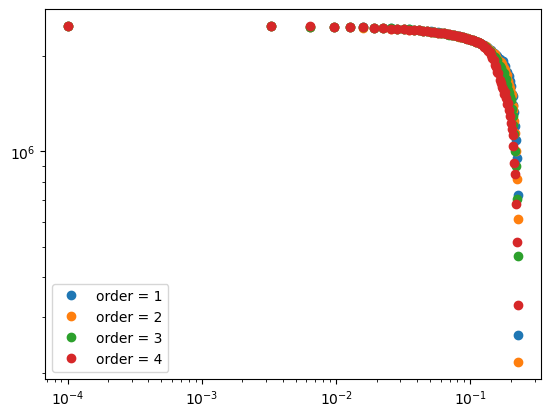

In [33]:
df_filter = df_clean_3d[df_clean_3d['dim']==3]
num_colors = 4
order = [i for i in range(1,num_colors+1)]
for ord in order:
    df_plot = df_filter[(df_filter["L"]==256) & (df_filter["order"]==ord) & (df_filter['p0']==1.0) & (df_filter['num_colors']==num_colors)].sort_values(['rho'])
    plt.plot(df_plot["rho"], df_plot["M_size_mean"],'o', label=f'order = {ord}')

plt.legend()
plt.yscale("log")
plt.xscale('log')
plt.show()